In [57]:
from generate_utils import load_GraphModel, load_BiLSTMModel, load_TokenBiLSTMModel
from models_graph import HarmonicGraphEncoder
import torch
import numpy as np
import pickle
from tqdm import tqdm
from GridMLM_tokenizers import CSGridMLMTokenizer
from graph_utils import get_graph_embeddings_from_string_with_model, get_bilstm_embeddings_from_string_with_model, graph_from_string, compare_heterodata

In [58]:
tokenizer = CSGridMLMTokenizer(
    fixed_length=80,
    quantization='4th',
    intertwine_bar_info=True,
    trim_start=False,
    use_pc_roll=True,
    use_full_range_melody=False
)

In [59]:
device_name = 'cuda:0'
device = torch.device(device_name)

graph_model_path = 'saved_models/LoRA/graph/graph_model_contra_jnhw.pt'
bilstm_model_path = 'saved_models/LoRA/bilstm/bilstm_model_jnhw.pt'
token_model_path = 'saved_models/LoRA/token_bilstm/bilstm_model_jnhw.pt'

In [60]:
graph_model = load_GraphModel(graph_model_path, device)
bilstm_model = load_BiLSTMModel(bilstm_model_path, device)
token_model = load_TokenBiLSTMModel(token_model_path, tokenizer, device)

In [61]:
graph_model.eval()
bilstm_model.eval()
token_model.eval()

TokenHarmonyBiLSTM(
  (embedding): Embedding(355, 256, padding_idx=0)
  (lstm): LSTM(256, 256, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (attn): Linear(in_features=512, out_features=1, bias=True)
  (output_proj): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=512, bias=True)
  )
)

In [62]:
datasets = {
    'gjt': {'path': 'data/gjt_test.pkl', 'dataset': None},
    # 'hook': {'path': 'data/hook_test.pkl', 'dataset': None},
    'nott': {'path': 'data/nott_test.pkl', 'dataset': None},
    # 'wiki': {'path': 'data/wiki_test.pkl', 'dataset': None}
}

In [63]:
for k, v in datasets.items():
    print(f'loading {k}')
    with open(v['path'], 'rb') as f:
        d = pickle.load(f)
    v['dataset'] = d

loading gjt


loading nott


In [64]:
graph_embeddings = []
bilstm_embeddings = []
token_embeddings = []
metadata = []

for k,v in datasets.items():
    for i, d in tqdm(enumerate(v['dataset'])):
        g = d['graph_ready_object']
        bar_objects = g.bar_objects
        for bar_start in range(len(bar_objects)-2):
            bar_end = bar_start + 2
            # graph
            g.make_graph_of_segment(bar_start, bar_end)
            z_graph = graph_model(g.segment_graph.to(device))
            graph_embeddings.append(
                z_graph.detach().cpu().numpy()
            )
            # bilstm
            g.make_bilstm_seq_of_segment(bar_start, bar_end)
            segment_bilstm = g.segment_bilstm.unsqueeze(0)
            lengths = torch.tensor(segment_bilstm.shape[1], dtype=int).unsqueeze(0)
            z_bilstm = bilstm_model(segment_bilstm.to(device), lengths.to(device))
            bilstm_embeddings.append(
                z_bilstm.detach().cpu().numpy()
            )
            # # token
            # z_token = token_model(segment_bilstm.to(device), lengths.to(device))
            # token_embeddings.append(
            #     z_token.detach().cpu().numpy()
            # )
            # make string of chord symbols
            chords_str = f'{k}_{i}_[{bar_start}, {bar_end}]<br>'
            for bar_idx in range(bar_start, bar_end):
                chords_str += 'b_'
                for chord in bar_objects[bar_idx].chord_objects:
                    mel_pcs = [r.tolist() for pcs in chord.melody_pcs for r in pcs]
                    mel_pcs = list( set(mel_pcs) )
                    chords_str += tokenizer.ids_to_tokens[chord.chord_id] + '_@' + str(len(chord.bar_positions)) + \
                                    '_m' + repr(mel_pcs) + '<br>'
            metadata.append({
                'dataset': k,
                'piece_idx': i,
                'bar_start': bar_start,
                'bar_end': bar_end,
                'chords': chords_str
            })

graph_embeddings = np.vstack(graph_embeddings)
bilstm_embeddings = np.vstack(bilstm_embeddings)
# token_embeddings = np.vstack(token_embeddings)

28it [00:01, 15.82it/s]
45it [00:03, 14.49it/s]


In [65]:
print(graph_embeddings.shape)
print(bilstm_embeddings.shape)

(1054, 512)
(1054, 512)


In [66]:
print(metadata[100])

{'dataset': 'gjt', 'piece_idx': 7, 'bar_start': 8, 'bar_end': 10, 'chords': 'gjt_7_[8, 10]<br>b_F:maj7_@2_m[0, 9]<br>E:min7_@2_m[9, 11, 4, 7]<br>b_F:maj7_@2_m[9]<br>E:min7_@2_m[9]<br>'}


In [67]:
# in_seq_1 = 'b_C:maj_@2_m[0,4,9];A:7_@2_m[1,4]b_D:min_@2_m[2,5,7];G:7_@2_m[5,9,11]'
# in_seq_2 = 'b_C:maj_@2_m[0,4];A:7_@2_m[1,7]b_D:min_@2_m[2,5,9];G:7_@2_m[5,9,2]'
# in_seq_3 = 'b_A:7_@2_m[1,4];D:min_@2_m[2,5,7]b_G:7_@2m[5,9,11];C:maj_@2_m[0,4,9]'
# in_seq_4 = 'b_D:min_@2_m[2,5,7];G:7_@2_m[5,9,11]b_C:maj_@2_m[0,4,9];A:7_@2_m[1,4]'

# in_seq_1 = 'b_C:maj_@2_m[0,4,9];A:7_@2_m[1,4]b_D:min_@4_m[2,5,7]'
# in_seq_2 = 'b_C:maj_@2_m[0,4];A:7_@2_m[1,7]b_D:min_@4_m[2,5,9]'
# in_seq_3 = 'b_A:7_@2_m[1,4];D:min_@2_m[2,5,7]b_G:7_@4m[5,9,11]'
# in_seq_4 = 'b_D:min_@0_m[2,5,7];G:7_@2_m[5,9,11]b_C:maj_@0_m[0,4,9]'

# in_seq_4 = 'b_E:min7_@2_m[2,7];D#:7_@2_m[7]b_G#:maj7_@2_m[7];G:7_@2_m[7]'
# in_seq_4 = 'b_E:min7_@2_m[2,7];D#:7_@2_m[7]b_G#:maj7_@2_m[7,1];G:7_@2_m[7]'
# in_seq_4 = 'b_A:min_@2_m[7];D#:7_@2_m[7]b_G#:maj7_@2_m[7];G:7_@2_m[7]'

# in_seq_1 = 'b_G:7_@2;C:maj_@2'
# in_seq_2 = 'b_G:9_@2;C:maj_@2'
# in_seq_3 = 'b_B:hdim7_@2;C:maj_@2'
# in_seq_4 = 'b_C#:7_@2;C:maj_@2'

# in_seq_1 = 'b_C:7_@2;F:maj_@2'
# in_seq_2 = 'b_C:9_@2;F:maj_@2'
# in_seq_3 = 'b_E:hdim7_@2;F:maj_@2'
# in_seq_4 = 'b_F#:7_@2;F:maj_@2'

# in_seq_1 = 'b_G:7_@2;C:maj7_@2'
# in_seq_2 = 'b_C:7_@2;F:maj7_@2'
# in_seq_3 = 'b_F:7_@2;A#:maj7_@2'
# in_seq_4 = 'b_A#:7_@2;D#:maj7_@2'

# in_seq_1 = 'b_B:7_@2;E:maj7_@2'
# in_seq_2 = 'b_E:7_@2;A:maj7_@2'
# in_seq_3 = 'b_A:7_@2;D:maj7_@2'
# in_seq_4 = 'b_D:7_@2;G:maj7_@2'

in_seq_1 = 'b_G:7_@2;C:maj7_@2'
in_seq_2 = 'b_G:7_@2;D:maj7_@2'
in_seq_3 = 'b_G:sus4_@4b_G:sus4@4'
in_seq_4 = 'b_A:min11_@4b_A:min11_@4'

# in_seq_1 = 'b_D:7(b9)_@2;G:maj_@2'
# in_seq_2 = 'b_D:9_@2;G:maj_@2'
# in_seq_3 = 'b_F#:hdim7_@2;G:maj_@2'
# in_seq_4 = 'b_G#:7_@2;G:maj_@2'

# in_seq_1 = 'b_C:maj7_@0;F:maj_@2'
# in_seq_2 = 'b_C:maj9_@0;F:maj_@2'
# in_seq_3 = 'b_E:min7_@0;F:maj_@2'
# in_seq_4 = 'b_A:min7_@0;F:maj_@2'

# in_seq_1 = 'b_D:min7_@0;G:7_@2'
# in_seq_2 = 'b_D:min9_@0;G:7_@2'
# in_seq_3 = 'b_F:maj7_@0;G:7_@2'
# in_seq_4 = 'b_A:min7_@0;G:7_@2'

# in_seq_1 = 'b_E:min7_@0;A:7_@2'
# in_seq_2 = 'b_E:min9_@0;A:7_@2'
# in_seq_3 = 'b_G:maj7_@0;A:7_@2'
# in_seq_4 = 'b_B:min7_@0;A:7_@2'

# in_seq_1 = 'b_F#:min7_@0;B:7_@2'
# in_seq_2 = 'b_F#:min9_@0;B:7_@2'
# in_seq_3 = 'b_A:maj7_@0;B:7_@2'
# in_seq_4 = 'b_C#:min7_@0;B:7_@2'

# in_seq_1 = 'b_B:min7_@0;E:7_@2'
# in_seq_2 = 'b_B:min9_@0;E:7_@2'
# in_seq_3 = 'b_D:maj7_@0;E:7_@2'
# in_seq_4 = 'b_F#:min7_@0;E:7_@2'

# in_seq_1 = 'b_B:min7_@0b_E:7_@0'
# in_seq_2 = 'b_B:min9_@0b_E:7_@0'
# in_seq_3 = 'b_D:maj7_@0b_E:7_@0'
# in_seq_4 = 'b_F#:min7_@0b_E:7_@0'

y_graph_1 = get_graph_embeddings_from_string_with_model(in_seq_1, graph_model)
y_graph_2 = get_graph_embeddings_from_string_with_model(in_seq_2, graph_model)
y_graph_3, m3 = get_graph_embeddings_from_string_with_model(in_seq_3, graph_model, return_mel_harm=True)
y_graph_4, m4 = get_graph_embeddings_from_string_with_model(in_seq_4, graph_model, return_mel_harm=True)

y_bilstm_1 = get_bilstm_embeddings_from_string_with_model(in_seq_1, bilstm_model)
y_bilstm_2 = get_bilstm_embeddings_from_string_with_model(in_seq_2, bilstm_model)
y_bilstm_3 = get_bilstm_embeddings_from_string_with_model(in_seq_3, bilstm_model)
y_bilstm_4 = get_bilstm_embeddings_from_string_with_model(in_seq_4, bilstm_model)

G:7 in vocab as: 216
C:maj7 in vocab as: 14
G:7 in vocab as: 216
D:maj7 in vocab as: 72
G:sus4 in vocab as: 214
unrecognized chord symbol G:sus4@4
A:min11 in vocab as: 285
A:min11 in vocab as: 285
G:7 in vocab as: 216
C:maj7 in vocab as: 14
G:7 in vocab as: 216
D:maj7 in vocab as: 72
G:sus4 in vocab as: 214
unrecognized chord symbol G:sus4@4
A:min11 in vocab as: 285
A:min11 in vocab as: 285


In [68]:
m3.print_info()

Number of bars: 2
Segment bar range: [0, 2)
Segment graph features:
HeteroData(
  pitch={ x=[12, 12] },
  event={
    num_nodes=1,
    x=[1, 1],
  },
  (pitch, participates, event)={
    edge_index=[2, 3],
    edge_attr=[3, 5],
  },
  (event, next, event)={
    edge_index=[2, 0],
    edge_attr=[0],
  }
)
Segment graph bars:
Bar 1:
Bar token positions: [2, 2]
Number of chord objects in bar: 1
Chord object 1:
Chord label: G:sus4
Pitch classes: [0, 2, 7]
Root: 7
Chord ID: 214
Bar Positions: [0, 1]
Token Positions: [2, 2]
Graph Features:
tensor([[0., 0., 0., 0., 1.],
        [0., 0., 1., 0., 0.],
        [1., 0., 0., 0., 0.]])
BiLSTM Features
tensor([1., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0.])
Bar 2:
Bar token positions: []
Number of chord objects in bar: 0
Bar 1:
Bar token positions: [2, 2]
Number of chord objects in bar: 1
Chord object 1:
Chord label: G:sus4
Pitch classes: [0, 2, 7]
Root: 7
Chord ID: 214
Bar Positions: [0, 1]
Token Positions: [2, 2]
Graph Features:
tensor([[0., 0., 

In [69]:
m4.print_info()

Number of bars: 2
Segment bar range: [0, 2)
Segment graph features:
HeteroData(
  pitch={ x=[12, 12] },
  event={
    num_nodes=2,
    x=[2, 1],
  },
  (pitch, participates, event)={
    edge_index=[2, 12],
    edge_attr=[12, 5],
  },
  (event, next, event)={
    edge_index=[2, 1],
    edge_attr=[1, 6],
  }
)
Segment graph bars:
Bar 1:
Bar token positions: [2, 2]
Number of chord objects in bar: 1
Chord object 1:
Chord label: A:min11
Pitch classes: [0, 2, 4, 7, 9, 11]
Root: 9
Chord ID: 285
Bar Positions: [0, 1]
Token Positions: [2, 2]
Graph Features:
tensor([[0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 1.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0.],
        [1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1.]])
BiLSTM Features
tensor([1., 0., 1., 0., 1., 0., 0., 1., 0., 1., 0., 1.])
Bar 2:
Bar token positions: [2, 2]
Number of chord objects in bar: 1
Chord object 1:
Chord label: A:min11
Pitch classes: [0, 2, 4, 7, 9, 11]
Root: 9
Chord ID: 285
Bar Positions: [0, 1]
Token

In [70]:
cos = torch.nn.CosineSimilarity()
print(cos(y_graph_3, y_graph_4))

tensor([0.3908], device='cuda:0')


In [71]:
from sklearn.decomposition import PCA

In [72]:
pca_graph = PCA(n_components=2)
pca_bilstm = PCA(n_components=2)

In [73]:
y_graph = pca_graph.fit_transform(graph_embeddings)
y_bilstm = pca_bilstm.fit_transform(bilstm_embeddings)

In [ ]:
# transform new points
new_graph = np.vstack([
    y_graph_1.detach().cpu().numpy(),
    y_graph_2.detach().cpu().numpy(),
    y_graph_3.detach().cpu().numpy(),
    y_graph_4.detach().cpu().numpy(),
])

new_bilstm = np.vstack([
    y_bilstm_1.detach().cpu().numpy(),
    y_bilstm_2.detach().cpu().numpy(),
    y_bilstm_3.detach().cpu().numpy(),
    y_bilstm_4.detach().cpu().numpy(),
])

# new_gra/ph÷_2d = pca_graph.transform(new_graph)
new_bilstm_2d = pca_bilstm.transform(new_bilstm//)

In [75]:
# print(y_graph.shape, y_bilstm.shape)

In [76]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
# import plotly.io as pio
# pio.renderers.default = "browser"

In [77]:
chords_list = [metadata[i]['chords'] for i in range(len(y_graph))]
datasets_list = [metadata[i]['dataset'] for i in range(len(y_graph))]
df_graph = pd.DataFrame({
    'x': y_graph[:,0],
    'y': y_graph[:,1],
    'chords': chords_list,
    'dataset': datasets_list
})
fig = px.scatter(
    data_frame=df_graph,
    x='x',
    y='y',
    color='dataset',
    color_discrete_sequence=px.colors.qualitative.Pastel,
    hover_data=['chords'],
)
fig.add_trace(go.Scatter(
    x=new_graph_2d[:, 0],
    y=new_graph_2d[:, 1],
    mode='markers+text',
    marker=dict(color='red', size=10, symbol='x'),
    text=['y1', 'y2', 'y3', 'y4'],
    hovertext=[
        in_seq_1.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_2.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_3.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_4.replace(';','<br>').replace('b_', '<br>b_'),
    ],
    hoverinfo='text',
    textposition='top center',
    name='new graph points'
))
fig.show()

# fig = px.scatter(
#     data_frame=df,
#     x='x',
#     y='y',
#     hover_data=['chords']
# )
# fig.show()

In [78]:
# chords_list = [metadata[i]['chords'] for i in range(len(y_graph))]
df_bilstm = pd.DataFrame({
    'x': y_bilstm[:,0],
    'y': y_bilstm[:,1],
    'chords': chords_list,
    'dataset': datasets_list
})
fig = px.scatter(
    data_frame=df_bilstm,
    x='x',
    y='y',
    color='dataset',
    color_discrete_sequence=px.colors.qualitative.Pastel,
    hover_data=['chords']
)
fig.add_trace(go.Scatter(
    x=new_bilstm_2d[:, 0],
    y=new_bilstm_2d[:, 1],
    mode='markers+text',
    marker=dict(color='red', size=10, symbol='x'),
    text=['y1', 'y2', 'y3', 'y4'],
    hovertext=[
        in_seq_1.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_2.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_3.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_4.replace(';','<br>').replace('b_', '<br>b_'),
    ],
    hoverinfo='text',
    textposition='top center',
    name='new bilstm points'
))
fig.show()

# fig = px.scatter(
#     data_frame=df,
#     x='x',
#     y='y',
#     hover_data=['chords']
# )
# fig.show()

In [79]:
d = datasets['gjt']['dataset'][17]
d['graph_ready_object'].make_graph_of_segment(13,15)
d['graph_ready_object'].make_bilstm_seq_of_segment(13,15)

In [80]:
g = graph_from_string(in_seq_4)

A:min11 in vocab as: 285
A:min11 in vocab as: 285


In [81]:
d['graph_ready_object'].print_info()
g.print_info()

Number of bars: 16
Segment bar range: [13, 15)
Segment graph features:
HeteroData(
  pitch={ x=[12, 12] },
  event={
    num_nodes=2,
    x=[2, 1],
  },
  (pitch, participates, event)={
    edge_index=[2, 12],
    edge_attr=[12, 5],
  },
  (event, next, event)={
    edge_index=[2, 1],
    edge_attr=[1, 6],
  }
)
Segment graph bars:
Bar 14:
Bar token positions: [66, 67, 68, 69]
Number of chord objects in bar: 1
Chord object 1:
Chord label: A#:min11
Pitch classes: [0, 1, 3, 5, 8, 10]
Root: 10
Chord ID: 314
Bar Positions: [0, 1, 2, 3]
Token Positions: [66, 67, 68, 69]
Graph Features:
tensor([[0., 0., 0., 0., 1.],
        [0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 1.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0.],
        [1., 0., 0., 0., 0.]])
BiLSTM Features
tensor([1., 1., 0., 1., 0., 1., 0., 0., 1., 0., 1., 0.])
Bar 15:
Bar token positions: [71, 72, 73, 74]
Number of chord objects in bar: 1
Chord object 1:
Chord label: A#:min11
Pitch classes: [0, 1, 3, 5, 8, 10]
Root:

In [82]:
graph_dataset = d['graph_ready_object'].segment_graph
graph_string = g.segment_graph

In [83]:
print(type(graph_dataset))
print(type(graph_string))

<class 'torch_geometric.data.hetero_data.HeteroData'>
<class 'torch_geometric.data.hetero_data.HeteroData'>


In [84]:
print(graph_dataset.node_types, graph_string.node_types)
print(graph_dataset.edge_types, graph_string.edge_types)

print(graph_dataset["event"].num_nodes, graph_string["event"].num_nodes)
print(graph_dataset["pitch","participates","event"].edge_index.shape,
      graph_string["pitch","participates","event"].edge_index.shape)

['pitch', 'event'] ['pitch', 'event']
[('pitch', 'participates', 'event'), ('event', 'next', 'event')] [('pitch', 'participates', 'event'), ('event', 'next', 'event')]
2 2
torch.Size([2, 12]) torch.Size([2, 12])


In [85]:
diffs = compare_heterodata(graph_dataset, graph_string)
print("differences:", diffs)

differences: ["('pitch', 'participates', 'event').edge_index values differ", ' first diff edge_index at [[0, 1], [0, 2], [0, 3], [0, 4], [0, 5]]']


In [86]:
print(graph_dataset["event"].num_nodes)
print(graph_string["event"].num_nodes)

2
2


In [87]:
print(graph_dataset['event', 'next', 'event'].edge_attr)
print(graph_string['event', 'next', 'event'].edge_attr)

tensor([[1., 1., 1., 0., 0., 0.]])
tensor([[1., 1., 1., 0., 0., 0.]])


In [88]:
with torch.no_grad():
    test_graph_dataset = graph_model(d['graph_ready_object'].segment_graph)
with torch.no_grad():
    test_graph_string = graph_model(g.segment_graph)

In [89]:
with torch.no_grad():
    test_bilstm_dataset = bilstm_model(
        d['graph_ready_object'].segment_bilstm.unsqueeze(0).to(device),
        torch.tensor([d['graph_ready_object'].segment_bilstm.shape[0]]).to(device)
    )
with torch.no_grad():
    test_bilst_string = bilstm_model(
        g.segment_bilstm.unsqueeze(0).to(device),
        torch.tensor([g.segment_bilstm.shape[0]]).to(device)
    )

In [90]:
import matplotlib.pyplot as plt

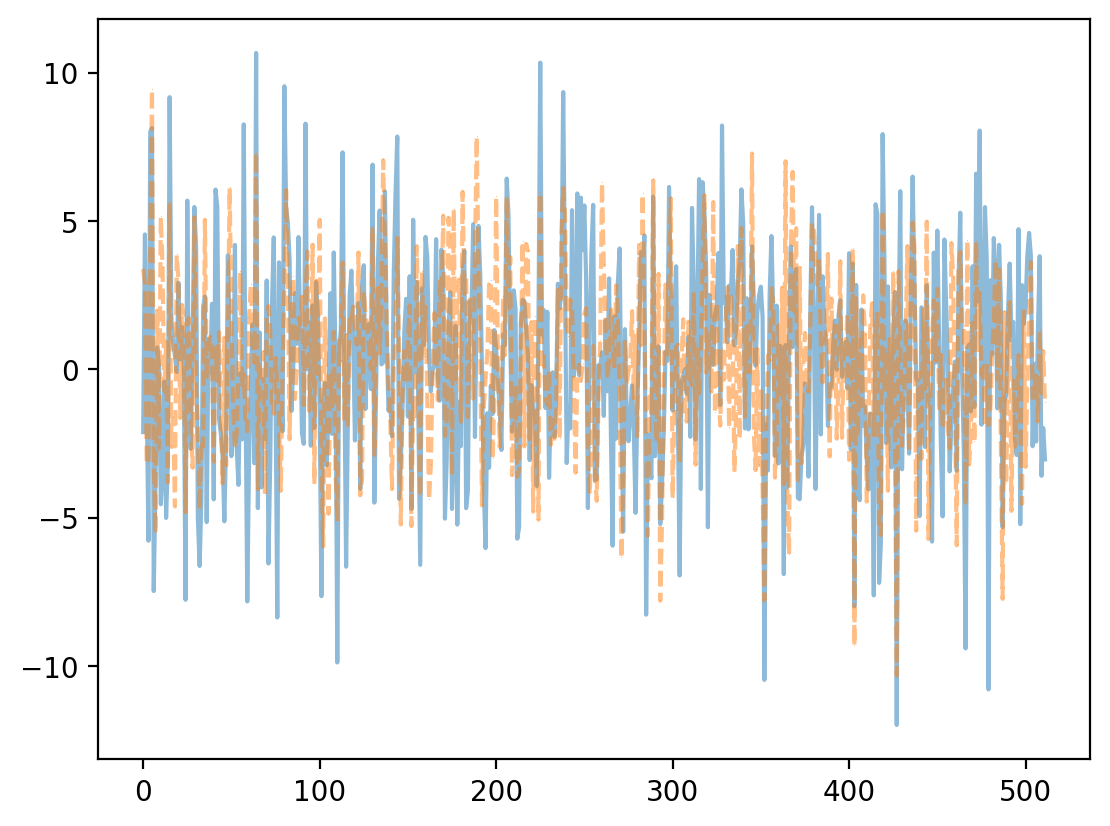

In [91]:
plt.plot(test_graph_dataset.detach().cpu().numpy(), alpha = 0.5)
plt.plot(test_graph_string.detach().cpu().numpy(), '--,', alpha = 0.5)

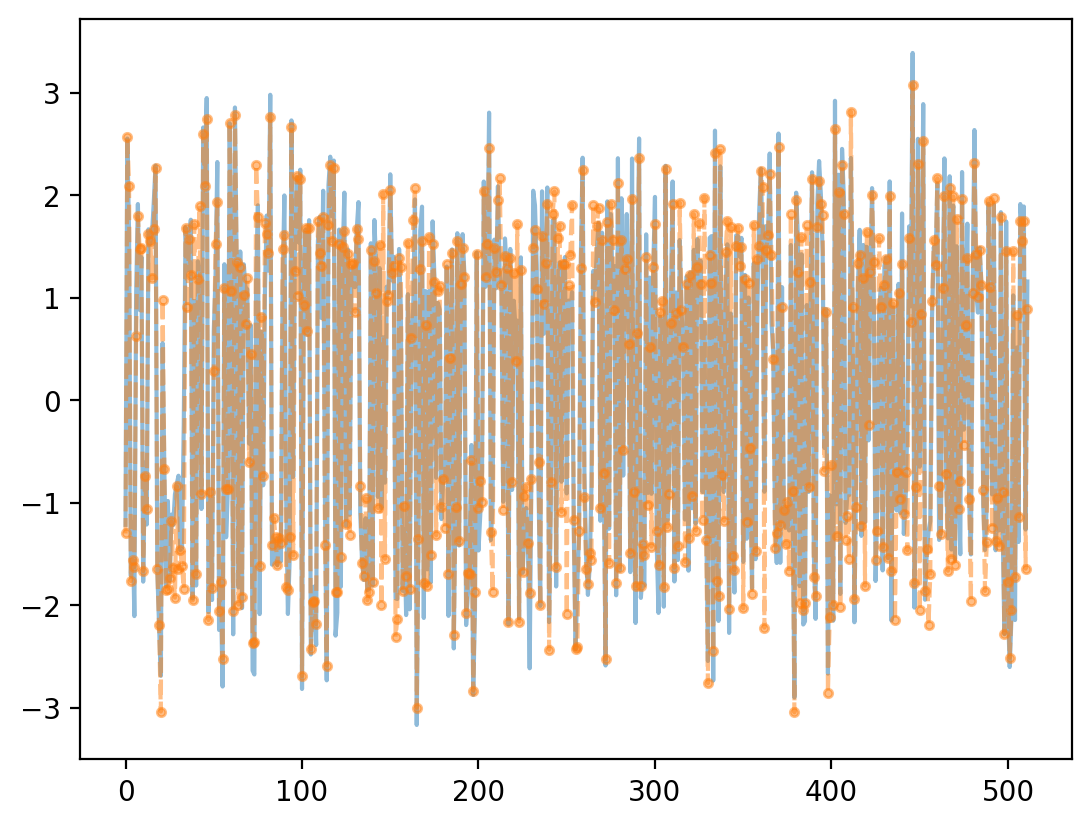

In [92]:
plt.plot(test_bilstm_dataset[0].detach().cpu().numpy(), alpha = 0.5)
plt.plot(test_bilst_string[0].detach().cpu().numpy(), '--.', alpha = 0.5)

In [93]:
print(g.segment_bilstm.shape)
print(d['graph_ready_object'].segment_bilstm.shape)

torch.Size([2, 12])
torch.Size([2, 12])


In [94]:
sorted_x_idxs = np.argsort(y_graph[:,0])
# sorted_x_idxs = np.argsort(y_bilstm[:,0])
print(sorted_x_idxs)
print(chords_list[sorted_x_idxs[0]])
print(chords_list[sorted_x_idxs[-1]])

sorted_y_idxs = np.argsort(y_graph[:,1])
# sorted_y_idxs = np.argsort(y_bilstm[:,1])
print(sorted_y_idxs)
print(chords_list[sorted_y_idxs[0]])
print(chords_list[sorted_y_idxs[-1]])

[739 723 559 ... 700 704 712]
nott_21_[22, 24]<br>b_G:maj_@2_m[5, 7]<br>b_G:7_@2_m[2, 3, 4, 7]<br>
nott_20_[12, 14]<br>b_C:maj_@3_m[0, 11, 4]<br>b_G:maj_@1_m[9, 7]<br>A:min_@2_m[0, 11]<br>
[821 814 823 ... 853 831 839]
nott_28_[6, 8]<br>b_G:7_@2_m[0, 9, 2, 11]<br>C:maj_@2_m[0, 4, 7]<br>b_A:min_@2_m[0, 2, 4, 5]<br>D:min_@2_m[0, 2, 11]<br>
nott_29_[11, 13]<br>b_C:maj_@4_m[0, 2, 4]<br>b_C:maj_@4_m[4, 5]<br>


In [95]:
graph_seqs = ''

# print left-most
print('left-most chord sequences:')
graph_seqs += 'left-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = 0
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_x_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        graph_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i += 1
print('')
graph_seqs += '\n'

# print right-most
print('right-most chord sequences:')
graph_seqs += 'right-most chord sequences:' + '\n'
printed_seqs = 0
prev_seq = ''
i = -1
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_x_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        graph_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i -= 1
print('')
graph_seqs += '\n'

# print bottom-most
print('bottom-most chord sequences:')
graph_seqs += 'bottom-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = 0
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_y_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        graph_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i += 1
print('')
graph_seqs += '\n'

# print top-most
print('top-most chord sequences:')
graph_seqs += 'top-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = -1
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_y_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        graph_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i -= 1

left-most chord sequences:
G:maj  G:7  
G:maj  G:maj  
G:7  G:7  
G:9  G:7  
E:min7  E:min7  
G:9  G:9  
B:hdim7  E:7(b9)  
D:min  G:7  
B:hdim7  E:7  
E:7(b9)  D:min6  
A:7(#11)  G:7  
E:sus4  E:7(b9)  
F:maj  G:7  
E:min7  A:13  
G:min7  G:7(#9)  
D:min7  G:7  
G:maj7  E:min7  
F:maj6  G:7  
G:sus4  G:7  
E:min7  D:min9  

right-most chord sequences:
C:maj  G:maj A:min  
F:7 E:7  A:min7  
C:maj  G:maj C:maj  
C:maj G:maj  C:maj  
C:maj  G:maj C:maj  
C:maj G:maj  C:maj  
C:maj G:7  C:maj  
C:maj  G:7 C:maj  
C:maj G:7  C:maj  
C:maj  G:7 C:maj  
C:maj G:7  C:maj  
D:min7 E:7  A:min  
A:min  G:maj A:min  
B:aug E:7  A:min7  
C:maj G:7  A:min  
C:maj A#:maj  C:maj  
A:min G:7  C:maj  
D:7 G:7  C:maj6  
D:min E:7  A:min  
C:maj7 G:7(b9)  C:7  

bottom-most chord sequences:
G:7 C:maj  A:min D:min  
F:maj C:maj  A:min E:min  
D:min  A:min G:7  
A#:maj  C:maj A#:maj  
G:maj C:maj  F:maj  
E:min7  A:min7 E:min7  
G:7 C:maj  C:maj G:7  
D:min C:maj  G:7  
G:7  C:maj G:7  
G:maj C:maj  G:maj 

In [96]:
print(graph_seqs)

left-most chord sequences:
G:maj  G:7  
G:maj  G:maj  
G:7  G:7  
G:9  G:7  
E:min7  E:min7  
G:9  G:9  
B:hdim7  E:7(b9)  
D:min  G:7  
B:hdim7  E:7  
E:7(b9)  D:min6  
A:7(#11)  G:7  
E:sus4  E:7(b9)  
F:maj  G:7  
E:min7  A:13  
G:min7  G:7(#9)  
D:min7  G:7  
G:maj7  E:min7  
F:maj6  G:7  
G:sus4  G:7  
E:min7  D:min9  

right-most chord sequences:
C:maj  G:maj A:min  
F:7 E:7  A:min7  
C:maj  G:maj C:maj  
C:maj G:maj  C:maj  
C:maj  G:maj C:maj  
C:maj G:maj  C:maj  
C:maj G:7  C:maj  
C:maj  G:7 C:maj  
C:maj G:7  C:maj  
C:maj  G:7 C:maj  
C:maj G:7  C:maj  
D:min7 E:7  A:min  
A:min  G:maj A:min  
B:aug E:7  A:min7  
C:maj G:7  A:min  
C:maj A#:maj  C:maj  
A:min G:7  C:maj  
D:7 G:7  C:maj6  
D:min E:7  A:min  
C:maj7 G:7(b9)  C:7  

bottom-most chord sequences:
G:7 C:maj  A:min D:min  
F:maj C:maj  A:min E:min  
D:min  A:min G:7  
A#:maj  C:maj A#:maj  
G:maj C:maj  F:maj  
E:min7  A:min7 E:min7  
G:7 C:maj  C:maj G:7  
D:min C:maj  G:7  
G:7  C:maj G:7  
G:maj C:maj  G:maj 

In [97]:
# sorted_x_idxs = np.argsort(y_graph[:,0])
sorted_x_idxs = np.argsort(y_bilstm[:,0])
print(sorted_x_idxs)
print(chords_list[sorted_x_idxs[0]])
print(chords_list[sorted_x_idxs[-1]])

# sorted_y_idxs = np.argsort(y_graph[:,1])
sorted_y_idxs = np.argsort(y_bilstm[:,1])
print(sorted_y_idxs)
print(chords_list[sorted_y_idxs[0]])
print(chords_list[sorted_y_idxs[-1]])

[899 767 861 ... 290 168 169]
nott_34_[4, 6]<br>b_C:maj_@4_m[9, 10, 7]<br>b_C:maj_@4_m[4, 5, 7]<br>
gjt_12_[7, 9]<br>b_E:maj6_@2_m[1]<br>F#:min7_@1_m[1]<br>B:7_@1_m[]<br>b_E:maj6_@2_m[4]<br>C:min7_@1_m[]<br>F:7_@1_m[]<br>
[210 207 211 ... 728 984 777]
gjt_15_[6, 8]<br>b_G:min7_@2_m[0, 10, 2]<br>C:7_@2_m[0, 7]<br>b_A:min7_@1_m[0]<br>D:7_@1_m[0]<br>G:min7_@1_m[0]<br>C:7_@1_m[0]<br>
nott_24_[10, 12]<br>b_F:maj_@4_m[5]<br>b_F:maj_@4_m[0, 9]<br>


In [98]:
bilstm_seqs = ''

# print left-most
print('left-most chord sequences:')
bilstm_seqs += 'left-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = 0
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_x_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        bilstm_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i += 1
print('')
bilstm_seqs += '\n'

# print right-most
print('right-most chord sequences:')
bilstm_seqs += 'right-most chord sequences:' + '\n'
printed_seqs = 0
prev_seq = ''
i = -1
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_x_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        bilstm_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i -= 1
print('')
bilstm_seqs += '\n'

# print bottom-most
print('bottom-most chord sequences:')
bilstm_seqs += 'bottom-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = 0
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_y_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        bilstm_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i += 1
print('')
bilstm_seqs += '\n'

# print top-most
print('top-most chord sequences:')
bilstm_seqs += 'top-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = -1
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_y_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        bilstm_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i -= 1

left-most chord sequences:
C:maj  C:maj  
A:min  C:maj  
C:maj  A:min  
A:min  A:min  
C:maj  C:maj A:min  
A:min  A:min C:maj  
C:maj  G:maj C:maj  
C:maj G:maj  C:maj  
C:maj  G:maj C:maj  
C:maj G:maj  C:maj  
C:maj  G:maj C:maj  
C:maj G:maj  C:maj  
C:maj  G:maj C:maj  
C:maj  C:maj G:maj  
G:maj  C:maj  
G:maj C:maj  C:maj  
C:maj  G:maj  
C:maj  G:maj A:min  
A:min  G:maj A:min  
G:maj C:maj  G:maj  

right-most chord sequences:
E:maj6 F#:min7 B:7  E:maj6 C:min7 F:7  
E:maj7 F#:min7 B:sus4  E:maj6 F#:min7 B:7  
F#:min7 B:7(b13)  E:maj7 B:min7 E:7  
E:maj7 B:min7 E:7  D#:min7 G#:7  
C:maj6 B:min7 E:7  C:maj6 A#:min7 D#:7  
A#:maj7 A:aug  G:min7 C:7 B:7  
A:min7 D:7 G:min7 C:7  F:maj6 B:hdim7 E:7  
F#:hdim7  E:maj7 F#:min7 B:sus4  
C:maj6 A#:min7 D#:7  G#:maj7 F:min7  
F#:min7 D:7  G:maj7 C#:7(#11)  
G#:maj6 F:aug  A#:min7 D#:7  
A:maj7 F#:min7  B:min7 E:7  
C#:min7 F#:7  B:min7 E:7  
B:min7 E:7  A:maj7 F#:min7  
A#:min9 D#:7  G#:maj6 F:aug  
F#:7 B:7  E:min7 D#:7  
E:maj6 C:min7 

In [99]:
print(bilstm_seqs)

left-most chord sequences:
C:maj  C:maj  
A:min  C:maj  
C:maj  A:min  
A:min  A:min  
C:maj  C:maj A:min  
A:min  A:min C:maj  
C:maj  G:maj C:maj  
C:maj G:maj  C:maj  
C:maj  G:maj C:maj  
C:maj G:maj  C:maj  
C:maj  G:maj C:maj  
C:maj G:maj  C:maj  
C:maj  G:maj C:maj  
C:maj  C:maj G:maj  
G:maj  C:maj  
G:maj C:maj  C:maj  
C:maj  G:maj  
C:maj  G:maj A:min  
A:min  G:maj A:min  
G:maj C:maj  G:maj  

right-most chord sequences:
E:maj6 F#:min7 B:7  E:maj6 C:min7 F:7  
E:maj7 F#:min7 B:sus4  E:maj6 F#:min7 B:7  
F#:min7 B:7(b13)  E:maj7 B:min7 E:7  
E:maj7 B:min7 E:7  D#:min7 G#:7  
C:maj6 B:min7 E:7  C:maj6 A#:min7 D#:7  
A#:maj7 A:aug  G:min7 C:7 B:7  
A:min7 D:7 G:min7 C:7  F:maj6 B:hdim7 E:7  
F#:hdim7  E:maj7 F#:min7 B:sus4  
C:maj6 A#:min7 D#:7  G#:maj7 F:min7  
F#:min7 D:7  G:maj7 C#:7(#11)  
G#:maj6 F:aug  A#:min7 D#:7  
A:maj7 F#:min7  B:min7 E:7  
C#:min7 F#:7  B:min7 E:7  
B:min7 E:7  A:maj7 F#:min7  
A#:min9 D#:7  G#:maj6 F:aug  
F#:7 B:7  E:min7 D#:7  
E:maj6 C:min7 

In [100]:
from ollama import chat
from ollama import ChatResponse

response: ChatResponse = chat(model='qwen2.5-coder:7b', messages=[
  {
    'role': 'user',
    'content': 'Can you commend on sequences of musical chords? \
        For example, which chord sequence is more common: a) G:7 C:maj7 or b)C#:7 C:maj7?',
  },
])
print(response['message']['content'])
# or access fields directly from the response object
# print(response.message.content)

ConnectionError: Failed to connect to Ollama. Please check that Ollama is downloaded, running and accessible. https://ollama.com/download

In [ ]:
response: ChatResponse = chat(model='qwen2.5-coder:7b', messages=[
  {
    'role': 'user',
    'content': f'You are a music harmony expert and you role is to provide \
    comments on chord progressions that appear within two PCA-projected spaces. \
    These PCA spaces were produced by two models that process symbolic music \
    harmony and we are interested in explaining whether there is something \
    specific that the first two axes represent (left-right and bottom-top). \
    These spaces were formed by the same short chord sequences and we only use \
    the ones on the extreme edges in the analysis.\
    We are interested in understanding if Model 1 or Model 2 \
    have generated more musically meaningful representations and which one is better. \
    Keep in mid that both Models are trained on pieces in C major and A minor \
    and that the sequences they processes are segments of C major - A minor pieces. \
    Below are the Sets positioned in the respective PCA spaces by each model. \
    Here is Set 1: `{bilstm_seqs}`. \n\n \
    Here is Set 2: `{graph_seqs}`.\n \
    If you had to pick a model, who would that be and why?',
  },
])
print(response['message']['content'])

When comparing two models based on their performance in PCA-projected spaces, it is important to consider the distribution of chord sequences across the dimensions represented by the first two axes. Let's analyze the given sets for both Model 1 and Model 2.

### Analysis of Set 1

**Left-most Chord Sequences:**
- The leftmost set contains predominantly minor and major chords with some complex progressions like dim7 and sus4.
- It includes variations in tension and resolution, such as V7-I and ii-V-I progressions.

**Right-most Chord Sequences:**
- The rightmost set also includes a mix of minor and major chords but is slightly more complex with extended chords (e.g., A:min7 D:7 G:min7 C:7).
- It showcases advanced harmonic techniques like pedal points, modulations, and sophisticated voice leading.

**Bottom-most Chord Sequences:**
- The bottom set is dominated by relatively simple progressions, particularly I-V-I and ii-V-I in minor keys.
- It includes some tension-release patterns but 